<a href="https://colab.research.google.com/github/fasehab/Map_of_x_city/blob/main/lego_map.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# 🧱 LEGO STYLE CITY BUILDING HEIGHT MAP
# ============================================================
# Author: Fasehab Shaheen
# Description: Visualizes building heights of any city
#              using OpenStreetMap data in a Lego brick style
#              with volcanic color palette
#
# Data Source: OpenStreetMap via OSMnx
# Color: Volcanic (dark red → white) = low → high buildings
# ============================================================

In [1]:
!pip install osmnx
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import numpy as np
import osmnx as ox
import pandas as pd
from shapely.geometry import box
from scipy.spatial import cKDTree

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 4.9 MB/s eta 0:00:00


In [43]:
# ============================================================
# ⚙️ CHANGE THESE ONLY!
# ============================================================

CITY_NAME = "london"   # 🌍 Just type city name!
GRID_SIZE = 35        # higher = more detail, slower

# ============================================================
# 🗺️ CITY MAP
# Default = smaller districts (fast & optimized)
# Comment out default and uncomment FULL VERSION for entire city
# ⚠️ Full versions may take 5-15 mins for large cities!
# ============================================================
CITY_MAP = {

    # 🇬🇧 UK
    "london":       "Greater London, England",              # ✅ default
    # "london":     "Greater London, England",              # 🌍 same — already full city

    # 🇵🇰 Pakistan
    "lahore":       "Lahore District, Punjab, Pakistan",    # ✅ default
    # "lahore":     "Lahore, Punjab, Pakistan",             # 🌍 full city

    "karachi":      "Karachi Central, Sindh, Pakistan",     # ✅ default
    # "karachi":    "Karachi, Sindh, Pakistan",             # 🌍 full city

    # 🇦🇺 Australia
    "sydney":       "Sydney CBD, New South Wales, Australia",   # ✅ default
    # "sydney":     "Sydney, New South Wales, Australia",        # 🌍 full city

    # 🇺🇸 USA
    "new york":     "Manhattan, New York City, USA",        # ✅ default
    # "new york":   "New York City, New York, USA",         # 🌍 full city

    "chicago":      "Chicago Loop, Illinois, USA",          # ✅ default
    # "chicago":    "Chicago, Illinois, USA",               # 🌍 full city

    # 🇫🇷 France
    "paris":        "Paris 1er Arrondissement, France",     # ✅ default
    # "paris":      "Paris, Ile-de-France, France",         # 🌍 full city

    # 🇯🇵 Japan
    "tokyo":        "Shinjuku, Tokyo, Japan",               # ✅ default
    # "tokyo":      "Tokyo, Japan",                         # 🌍 full city ⚠️ very slow!

    "osaka":        "Namba, Osaka, Japan",                  # ✅ default
    # "osaka":      "Osaka City, Japan",                    # 🌍 full city

    # 🇦🇪 UAE
    "dubai":        "Downtown Dubai, UAE",                  # ✅ default
    # "dubai":      "Dubai, UAE",                           # 🌍 full city

    # 🇹🇷 Turkey
    "istanbul":     "Beyoglu, Istanbul, Turkey",            # ✅ default
    # "istanbul":   "Istanbul, Turkey",                     # 🌍 full city

    # 🇮🇳 India
    "delhi":        "New Delhi, Delhi, India",              # ✅ default
    # "delhi":      "Delhi, India",                         # 🌍 full city

    "mumbai":       "South Mumbai, Maharashtra, India",     # ✅ default
    # "mumbai":     "Mumbai, Maharashtra, India",           # 🌍 full city

    # 🇩🇪 Germany
    "berlin":       "Mitte, Berlin, Germany",               # ✅ default
    # "berlin":     "Berlin, Germany",                      # 🌍 full city

    # 🇨🇦 Canada
    "toronto":      "Downtown Toronto, Ontario, Canada",    # ✅ default
    # "toronto":    "Toronto, Ontario, Canada",             # 🌍 full city

    # ➕ ADD YOUR CITY BELOW!
    # "yourcity":   "District, City, Country",              # ✅ default
    # "yourcity":   "City, Country",                        # 🌍 full city
}

# ── Auto resolve ──────────────────────────────────────────
RESOLVED = CITY_MAP.get(CITY_NAME.lower(), CITY_NAME)
print(f"🗺️  City    : '{CITY_NAME}' → '{RESOLVED}'")
print(f"📐 Grid    : {GRID_SIZE}x{GRID_SIZE}")
print(f"🌍 Available: {list(CITY_MAP.keys())}")

🗺️  City    : 'london' → 'Greater London, England'
📐 Grid    : 35x35
🌍 Available: ['london', 'lahore', 'karachi', 'sydney', 'new york', 'chicago', 'paris', 'tokyo', 'osaka', 'dubai', 'istanbul', 'delhi', 'mumbai', 'berlin', 'toronto']


In [44]:
print(f"📍 Fetching buildings for {RESOLVED}...")

gdf = ox.features_from_place(
    RESOLVED,
    tags={"building": ["apartments", "residential", "office", "commercial"]}
)

# Safe column check
if 'building:levels' not in gdf.columns:
    print("⚠️ No building:levels column found — adding empty")
    gdf['building:levels'] = np.nan

gdf['building:levels'] = pd.to_numeric(gdf['building:levels'], errors='coerce')

print(f"✅ {len(gdf)} buildings fetched")
print(f"📊 building:levels non-null: {gdf['building:levels'].notna().sum()}")
gdf.head(3)

📍 Fetching buildings for Greater London, England...
✅ 130542 buildings fetched
📊 building:levels non-null: 45974


geometry    building      created_by  \
element id                                                                
node    33665768   POINT (-0.14172 51.3696)  apartments  Potlatch alpha   
        33717224  POINT (-0.14746 51.36227)  apartments            JOSM   
        33717267  POINT (-0.14653 51.36487)  apartments            JOSM   

                              name addr:city addr:housename addr:postcode  \
element id                                                                  
node    33665768  Marlesford Court       NaN            NaN           NaN   
        33717224      Orford Court       NaN            NaN           NaN   
        33717267      Maldon Court       NaN            NaN           NaN   

                 addr:street addr:housenumber addr:flats  ... fuel:octane_98  \
element id                                                ...                  
node    33665768         NaN              NaN        NaN  ...            NaN   
        33717224         NaN              NaN        NaN  ...            NaN   
        33717267         NaN              NaN        NaN  ...            NaN   

                 name:el name:ru name:ca name:eu name:it name:zh-Hant  \
element id                                                              
node    33665768     NaN     NaN     NaN     NaN     NaN          NaN   
        33717224     NaN     NaN     NaN     NaN     NaN          NaN   
        33717267     NaN     NaN     NaN     NaN     NaN          NaN   

                 contact:google_plus source:area source:flats  
element id                                                     
node    33665768                 NaN         NaN          NaN  
        33717224                 NaN         NaN          NaN  
        33717267                 NaN         NaN          NaN  

[3 rows x 630 columns]

🗺️ Fetching boundary & creating grid...
✅ Grid created: 833 cells


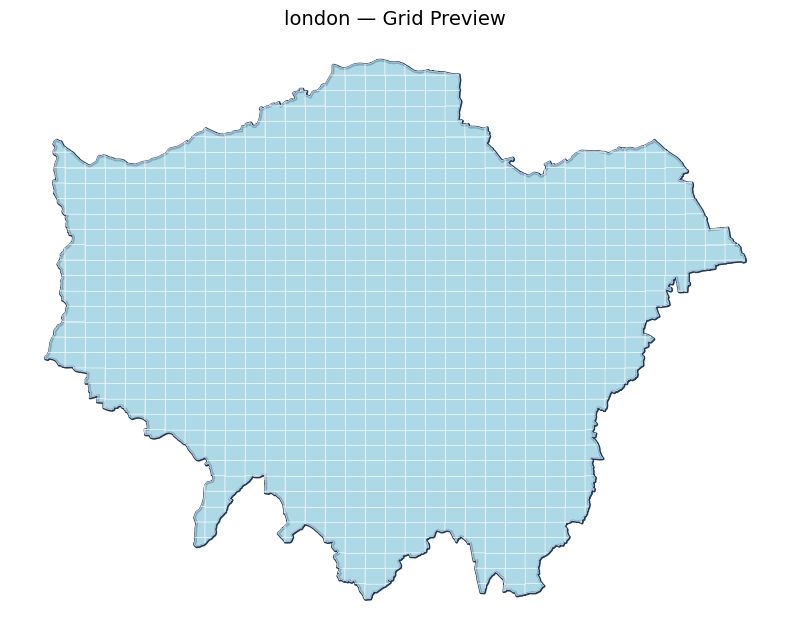

In [45]:
print("🗺️ Fetching boundary & creating grid...")

# Get city boundary
admin_city = ox.geocode_to_gdf(RESOLVED)
admin_city.crs = 4326

# Bounding box
bounds = admin_city.bounds
minx = bounds.minx.values[0]
miny = bounds.miny.values[0]
maxx = bounds.maxx.values[0]
maxy = bounds.maxy.values[0]

# Grid function
def create_grid(minx, miny, maxx, maxy, nx, ny):
    grid_polygons = []
    cw = (maxx - minx) / nx
    ch = (maxy - miny) / ny
    for i in range(nx):
        for j in range(ny):
            x = minx + i * cw
            y = miny + j * ch
            grid_polygons.append(box(x, y, x + cw, y + ch))
    return grid_polygons

# Build & clip grid
grid_polygons = create_grid(minx, miny, maxx, maxy, GRID_SIZE, GRID_SIZE)
gdf_grid = gpd.GeoDataFrame(grid_polygons, columns=['geometry'])
gdf_grid.crs = 4326
gdf_grid = gpd.clip(gdf_grid, admin_city)

print(f"✅ Grid created: {len(gdf_grid)} cells")

# Preview grid
f, ax = plt.subplots(1, 1, figsize=(8, 8))
admin_city.plot(ax=ax, color='#ADD8E6', edgecolor='#1B3A5C', linewidth=2)
gdf_grid.plot(ax=ax, color='#ADD8E6', edgecolor='white', alpha=0.7, linewidth=0.5)
ax.axis('off')
plt.title(f'{CITY_NAME} — Grid Preview', fontsize=14)
plt.tight_layout()
plt.show()

In [46]:
print("🔗 Running spatial join...")

joined = gpd.sjoin(gdf, gdf_grid, how="left", predicate="within")
aggregated = joined.groupby('index_right').agg(
    {'building:levels': 'mean'}
).reset_index()

gdf_grid['DN'] = gdf_grid.index.to_series().map(
    aggregated.set_index('index_right')['building:levels']
)

print(f"✅ Cells with data:    {gdf_grid['DN'].notna().sum()}")
print(f"📦 Total grid cells:  {len(gdf_grid)}")
print(f"📊 DN range:          {gdf_grid['DN'].dropna().min():.1f} → {gdf_grid['DN'].dropna().max():.1f} floors")

🔗 Running spatial join...
✅ Cells with data:    500
📦 Total grid cells:  833
📊 DN range:          0.0 → 14.5 floors


In [47]:
print("🔮 Interpolating missing cells...")

# Centroids for spatial interpolation
gdf_grid['cx'] = gdf_grid.geometry.centroid.x
gdf_grid['cy'] = gdf_grid.geometry.centroid.y

known   = gdf_grid[gdf_grid['DN'].notna()]
unknown = gdf_grid[gdf_grid['DN'].isna()]

# KD-Tree interpolation — fill empty cells from 5 nearest neighbors
if len(unknown) > 0 and len(known) > 0:
    tree = cKDTree(known[['cx', 'cy']].values)
    distances, indices = tree.query(unknown[['cx', 'cy']].values, k=5)
    weights = 1 / (distances + 1e-10)
    weighted_vals = np.average(
        known['DN'].values[indices],
        axis=1, weights=weights
    )
    gdf_grid.loc[gdf_grid['DN'].isna(), 'DN'] = weighted_vals
    print(f"✅ {len(unknown)} empty cells interpolated")

# Percentile stretch for better color spread
dn_min = np.percentile(gdf_grid['DN'].dropna(), 10)
dn_max = np.percentile(gdf_grid['DN'].dropna(), 90)
gdf_grid['DN_clipped'] = gdf_grid['DN'].clip(lower=dn_min, upper=dn_max)

# Scale to 0-24 levels
gdf_grid['height_level'] = gdf_grid['DN_clipped'].apply(
    lambda x: round(24 * (x - dn_min) / (dn_max - dn_min))
              if not np.isnan(x) else np.nan
)

print(f"✅ Scaling done")
print(f"📊 height_level range: {gdf_grid['height_level'].min()} → {gdf_grid['height_level'].max()}")

🔮 Interpolating missing cells...
✅ 333 empty cells interpolated
✅ Scaling done
📊 height_level range: 0 → 24


/tmp/ipykernel_13123/478428001.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_grid['cx'] = gdf_grid.geometry.centroid.x
/tmp/ipykernel_13123/478428001.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_grid['cy'] = gdf_grid.geometry.centroid.y


In [48]:
# ============================================================
# 🎨 UNCOMMENT YOUR THEME!
# ============================================================

# 🔥 Volcano/Fire (default)
# lego_colors = ['#1A0000', '#8B0000', '#CC0000', '#FF0000', '#FF4500',
#                '#FF6600', '#FF8800', '#FFAA00', '#FFCC00', '#FFFF00', '#FFFFFF']
# empty_colors = ['#FFD700', '#8B0000', '#FF4500', '#FF6600', '#CC0000', '#3D0000']
# bg_color    = '#1A0000'
# title_color = '#FF4500'

# 🎮 Synthwave
# lego_colors = ['#0D0221', '#7B00CC', '#FF00FF', '#FF0099', '#FF6600', '#FFFF00', '#00FFFF', '#FFFFFF']
# empty_colors = ['#FF00FF', '#FF0099', '#7B00CC', '#00FFFF', '#FF6600', '#3D0066']
# bg_color    = '#0D0221'
# title_color = '#FF00FF'

# 🌊 Ocean
lego_colors = ['#000033', '#000066', '#0000CC', '#0044FF', '#0088FF', '#00BBFF', '#00FFFF', '#88FFFF', '#CCFFFF', '#FFFFFF']
empty_colors = ['#00FFFF', '#000033', '#0000CC', '#0088FF', '#000066', '#00001A']
bg_color    = '#000033'
title_color = '#00FFFF'

# 💜 Ultraviolet
# lego_colors = ['#0D0015', '#2D0045', '#5500AA', '#8800FF', '#AA44FF', '#CC88FF', '#EECCFF', '#FFFFFF']
# empty_colors = ['#CC88FF', '#2D0045', '#8800FF', '#AA44FF', '#5500AA', '#1A0030']
# bg_color    = '#0D0015'
# title_color = '#AA44FF'

# 🥇 Gold Rush
# lego_colors = ['#1A1100', '#3D2800', '#7A5000', '#B8860B', '#DAA520', '#FFD700', '#FFE544', '#FFEE88', '#FFFFCC', '#FFFFFF']
# empty_colors = ['#FFD700', '#1A1100', '#B8860B', '#DAA520', '#7A5000', '#0D0800']
# bg_color    = '#1A1100'
# title_color = '#FFD700'

# ☢️ Toxic Green
# lego_colors = ['#001100', '#003300', '#006600', '#009900', '#00CC00', '#00FF00', '#66FF00', '#CCFF00', '#FFFF00', '#FFFFFF']
# empty_colors = ['#CCFF00', '#001100', '#006600', '#00FF00', '#003300', '#000D00']
# bg_color    = '#001100'
# title_color = '#00FF00'

print(f"✅ Theme loaded — bg: {bg_color}")

✅ Theme loaded — bg: #000033


🎨 Rendering Lego map...
💾 Saved: london_lego.png


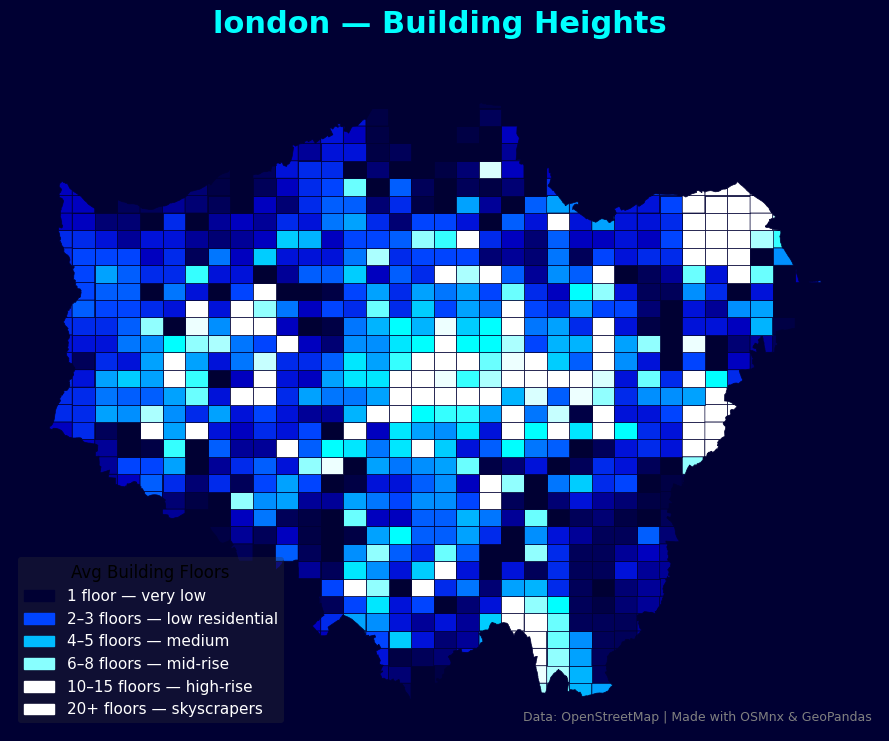

In [52]:
print("🎨 Rendering Lego map...")

# Directional empty cell colors
cx_min, cx_max = gdf_grid['cx'].min(), gdf_grid['cx'].max()
cy_min, cy_max = gdf_grid['cy'].min(), gdf_grid['cy'].max()

def assign_empty_color(row):
    if not np.isnan(row['height_level']):
        return None
    x_norm = (row['cx'] - cx_min) / (cx_max - cx_min)
    y_norm = (row['cy'] - cy_min) / (cy_max - cy_min)
    if x_norm > 0.6 and y_norm > 0.6:   return empty_colors[0]
    elif y_norm < 0.35:                   return empty_colors[1]
    elif x_norm < 0.35:                   return empty_colors[2]
    elif x_norm < 0.5 and y_norm > 0.6:  return empty_colors[3]
    elif x_norm > 0.6 and y_norm < 0.5:  return empty_colors[4]
    else:                                 return empty_colors[5]

gdf_grid['empty_color'] = gdf_grid.apply(assign_empty_color, axis=1)
gdf_has_data = gdf_grid[gdf_grid['height_level'].notna()].copy()
gdf_empty    = gdf_grid[gdf_grid['height_level'].isna()].copy()

lego_cmap = mcolors.LinearSegmentedColormap.from_list('lego_theme', lego_colors)

f, ax = plt.subplots(1, 1, figsize=(9, 9))
fig = plt.gcf()
fig.patch.set_facecolor(bg_color)
ax.set_facecolor(bg_color)

# Boundary
admin_city.plot(ax=ax, color=bg_color, edgecolor='none', linewidth=0)

# Empty cells
for color in gdf_empty['empty_color'].unique():
    subset = gdf_empty[gdf_empty['empty_color'] == color]
    subset.plot(ax=ax, color=color, edgecolor=bg_color, linewidth=0.5, alpha=0.85)

# Data cells
gdf_has_data.plot(
    ax=ax, column='height_level',
    edgecolor=bg_color, linewidth=0.5,
    cmap=lego_cmap, alpha=1.0,
)

# ── Custom Legend ──────────────────────────────────────
legend_labels = [
    (lego_colors[0],  '1 floor — very low'),
    (lego_colors[3],  '2–3 floors — low residential'),
    (lego_colors[5],  '4–5 floors — medium'),
    (lego_colors[7],  '6–8 floors — mid-rise'),
    (lego_colors[9],  '10–15 floors — high-rise'),
    (lego_colors[-1], '20+ floors — skyscrapers'),
]
patches = [
    mpatches.Patch(color=c, label=l)
    for c, l in legend_labels
]
ax.legend(
    handles=patches,
    loc='lower left',
    fontsize=11,
    framealpha=0.3,
    facecolor='#333333',
    edgecolor='none',
    labelcolor='white',
    title='Avg Building Floors',
    title_fontsize=12,
)

# ── Title & Credits ────────────────────────────────────
ax.set_title(
    f'{CITY_NAME} — Building Heights ',
    fontsize=22, color=title_color,
    fontweight='bold', pad=20
)
ax.text(
    0.99, 0.01,
    'Data: OpenStreetMap | Made with OSMnx & GeoPandas',
    transform=ax.transAxes,
    fontsize=9, color='grey',
    ha='right', va='bottom'
)

ax.axis('off')
plt.tight_layout()

# Save
filename = CITY_NAME.split(',')[0].replace(' ', '_').lower()
plt.savefig(f'{filename}_lego.png', dpi=800,
            bbox_inches='tight', facecolor=bg_color)
print(f"💾 Saved: {filename}_lego.png")
plt.show()